# Algoritmos de Búsqueda en Inteligencia Artificial

La búsqueda es una de las técnicas fundamentales en Inteligencia Artificial. Muchos problemas pueden plantearse como la búsqueda de una solución dentro de un espacio de posibles estados. Por ejemplo, encontrar la mejor jugada en un juego, planificar una ruta óptima o resolver un rompecabezas son tareas que pueden abordarse mediante algoritmos de búsqueda.

En este notebook estudiaremos algunos de los algoritmos clásicos de búsqueda,  **no informada** (como Búsqueda en Anchura o Búsqueda en Profundidad). En otro recurso estudiaremos los algoritmos de busqueda **informada** (como A* o Greedy). Estos algoritmos constituyen la base de muchos sistemas de IA más avanzados.

Comenzaremos con una definición formal del problema de búsqueda y luego exploraremos implementaciones en Python paso a paso.


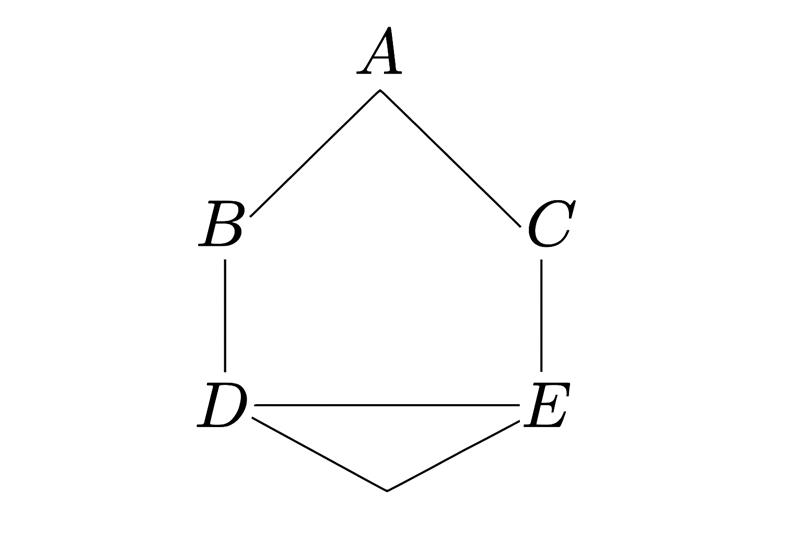

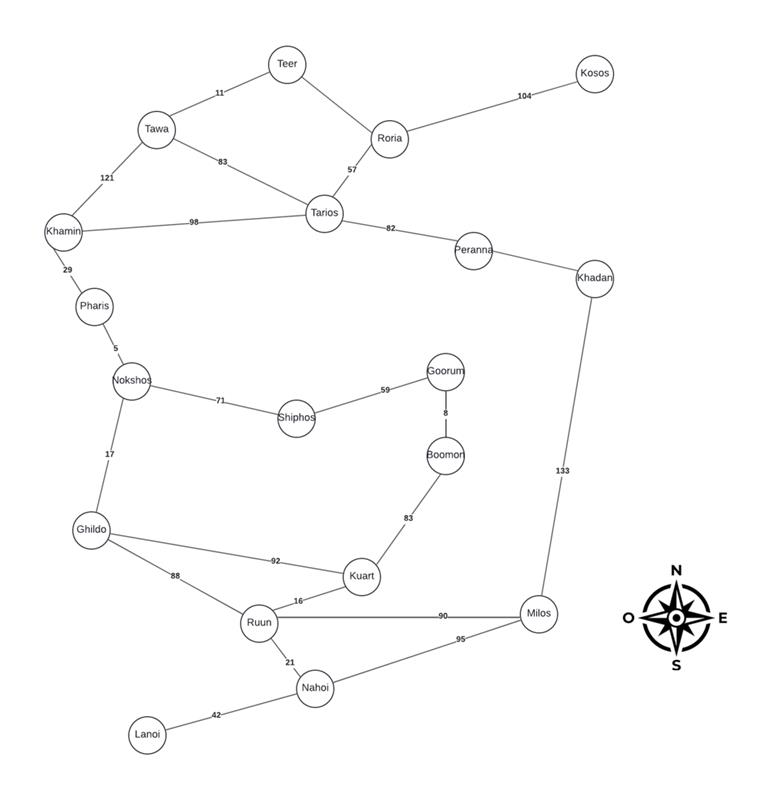

## Ejemplo introductorio: encontrar una ruta entre ciudades

Imagina que queremos viajar desde la ciudad **A** hasta la ciudad **E**, y tenemos un mapa de carreteras como el siguiente:


<div style="text-align: center;">
<img src="Grafo1.png" width="300"/>
</div>

Cada nodo representa una ciudad, y cada línea una carretera que conecta dos ciudades. Nuestro objetivo es encontrar una **ruta desde A hasta E**.

Podríamos explorar varias rutas posibles:

- A → B → D → E  
- A → C → E

¿Cuál ruta es mejor? ¿Cómo podríamos automatizar la búsqueda de rutas posibles?

Este tipo de problema es típico en Inteligencia Artificial, donde se plantea como un **problema de búsqueda en grafos**.



## Planteamiento general del problema de búsqueda

Formalmente, un **problema de búsqueda** consta de los siguientes elementos:

- **Estado inicial**: el punto de partida del agente.  
- **Espacio de estados**: el conjunto de todos los estados alcanzables desde el estado inicial, mediante las acciones posibles.  
- **Acciones**: el conjunto de movimientos permitidos desde un estado dado.  
- **Función de transición**: determina el nuevo estado resultante de aplicar una acción a un estado actual.  
- **Prueba de objetivo**: una función que permite verificar si un estado es una solución al problema.  
- **Costo de paso (opcional)**: si se desea optimizar el costo total del camino (como distancia o tiempo), se asigna un costo a cada acción.

---

### Aplicación al ejemplo de ciudades

En el problema introductorio, estos elementos se ven así:

- **Estado inicial**: ciudad A.  
- **Espacio de estados**: todas las ciudades del grafo.  
- **Acciones**: moverse por un camino hacia una ciudad vecina.  
- **Función de transición**: cambia la ciudad actual según el camino tomado.  
- **Prueba de objetivo**: verificar si hemos llegado a la ciudad E.  
- **Costo de paso**: (podría agregarse luego como la distancia entre ciudades).

Este esquema general permite aplicar distintos algoritmos de búsqueda para encontrar una secuencia de acciones (ruta) que nos lleve desde el estado inicial hasta un estado objetivo.


## Conceptos básicos sobre grafos

Para representar formalmente un problema de búsqueda, usaremos la estructura matemática llamada **grafo**. Un grafo es un conjunto de **nodos** (o **vértices**) conectados por **aristas** (o **enlaces**).

En el contexto de los algoritmos de búsqueda, un grafo nos permite modelar el espacio de estados del problema.

### Definición básica

Un **grafo** se define como un par $ G = (V, E) $, donde:

- $ V $ es un conjunto de nodos (vértices).
- $ E \subseteq V \times V $ es un conjunto de pares ordenados que representan las conexiones (aristas) entre nodos.

---

### Tipos de grafos relevantes

- **Grafo no dirigido**: las conexiones entre nodos no tienen dirección. Si hay una arista entre \( A \) y \( B \), se puede ir en ambos sentidos.
- **Grafo dirigido (o dígrafo)**: las aristas tienen dirección. Una arista de \( A \) a \( B \) no implica una de \( B \) a \( A \).
- **Grafo ponderado**: cada arista tiene un **costo** o **peso** asociado (por ejemplo, distancia, tiempo o costo económico).

---

### Terminología clave

- **Nodo o vértice**: punto del grafo que representa un estado o ciudad, por ejemplo.
- **Arista o enlace**: conexión entre dos nodos.
- **Camino**: secuencia de nodos conectados por aristas.
- **Camino solución**: camino desde el nodo inicial hasta un nodo objetivo.

---

En los algoritmos que estudiaremos, los grafos pueden ser dirigidos o no, y tener pesos o no, dependiendo del problema. En todos los casos, el objetivo será **buscar un camino desde un nodo inicial hasta un nodo objetivo**.


## Búsqueda en anchura (Breadth-First Search)

La **búsqueda en anchura** es un algoritmo de búsqueda no informada que explora el espacio de estados nivel por nivel. Comienza por el nodo raíz (estado inicial) y explora todos sus vecinos antes de pasar a los vecinos de esos vecinos, y así sucesivamente.

Este algoritmo garantiza encontrar la solución más cercana al estado inicial (es decir, con el menor número de pasos), siempre que todos los pasos tengan el mismo costo.

### Características

- **Estrategia**: Explora primero todos los nodos a una cierta profundidad antes de avanzar a la siguiente.
- **Estructura de datos**: Usa una **cola (FIFO)** para mantener los nodos pendientes de explorar.
- **Complejidad temporal**: \( O(b^d) \), donde \( b \) es el factor de ramificación y \( d \) la profundidad de la solución.
- **Complejidad espacial**: \( O(b^d) \), ya que necesita almacenar todos los nodos en memoria.
- **Óptima**: Sí, si todos los pasos tienen el mismo costo.
- **Completa**: Sí, encuentra una solución si existe.

### Ejemplo intuitivo

Volviendo al problema de encontrar una ruta entre ciudades, la búsqueda en anchura comenzaría en la ciudad **A**, luego visitaría todas las ciudades conectadas directamente a **A** (por ejemplo, **B** y **C**), y solo después exploraría los vecinos de **B** y **C**.

Esto permite encontrar la ruta más corta en términos de número de pasos, aunque no necesariamente la más barata si hay costos distintos asociados a los caminos.


**Ejemplo:** Considere el mapa de la imagen. Supón que queremos encontrar la mejor ruta entre Lanoi y Kosos. Usaremos este mapa para ilustrar la implementación y funcionamiento de los algorítmos de búsqueda no informada. 

<img src="Ciudades.png" alt="Grafo" width="750"/>

### Estructura de datos y clases para los algoritmos de búsqueda

En adelante describiremos la **estructura de datos** necesaria para implementar los algoritmos de búsqueda no informada (BFS, DFS y UCS), así como las **clases** que utilizaremos para modelar los elementos básicos del problema: acciones, estados, nodos y el propio problema.  

La idea es construir una base clara y modular para que luego los algoritmos puedan operar de forma sencilla sobre estos componentes.

#### Clase `Estado`
- **Propósito**: modela un estado del problema de forma sencilla, usando solo su nombre.
- **Atributos**:
  - `nombre`: (str) identifica el estado.
- **Métodos**:
  - `__str__`: devuelve el nombre del estado cuando se imprime.
- **Detalles**:
  - Se define como `@dataclass(frozen=True)` para hacerlo **inmutable** y **hashable**, lo que permite:
    - Usarlo en conjuntos (`set`) para registrar visitados.
    - Usarlo como clave en diccionarios (`dict`) para costos, heurísticas, etc.

#### Clase `Accion`
- **Propósito**: etiqueta o describe una transición entre estados.
- **Atributos**:
  - `nombre`: (str) nombre de la acción, por ejemplo `"A->B"` para ir de A a B.
- **Métodos**:
  - `__str__`: devuelve el nombre de la acción cuando se imprime.
- **Detalles**:
  - También se define con `@dataclass(frozen=True)`:
    - Inmutable y hashable.
    - Fácil de crear y comparar.
  - Permite reconstruir la **secuencia de acciones** que llevan a un estado meta, si el algoritmo las necesita.


In [1]:
#Busqueda primero en amplitud
#de la imagen compartida queremos encontrar una ruta entre Lanoi y Kosos 
#debemos represenar el conjuntos de acciones posibles en la exploración y el conjunto de estados posibles 


#definimos la clase de estados 
class Estado:
    def __init__(self, nombre, acciones):
        self.nombre = nombre
        self.acciones = acciones 
    def __str__(self):
        return self.nombre

class Accion:
    def __init__(self, nombre):
        self.nombre = nombre 
    def __str__(self):
        return self.nombre 



In [2]:
## Datos del problema: acciones 
accN = Accion('N') #acción norte
accS = Accion('S')#acción sur
accE = Accion('E')
accO = Accion('O')
accNE = Accion('NE')
accNO = Accion('NO')
accSE = Accion('SE')
accSO = Accion('SO')


In [3]:
#crear los estados 
lanoi = Estado('Lanoi',  [accNE]  )#estado lanoi
nahoi = Estado('Nahoi', [accSO, accNE, accNO])#estado Nahoi
ruun = Estado('Ruun', [accNO, accNE, accE, accSE])
milos = Estado('Milos', [accO, accSO, accN])
ghildo = Estado('Ghildo', [accN, accE, accSE])
kuart = Estado('Kuart', [accO, accSO, accNE])
boomon = Estado('Boomon', [accN, accSO])
goorum = Estado('Goorum', [accO, accS])
shiphos = Estado('Shiphos', [accO, accE])
nokshos = Estado('Nokshos', [accNO, accS, accE])
pharis = Estado('Pharis', [accNO, accSO])
khamin = Estado('Khamin', [accSE, accNO, accO])
tarios = Estado('Tarios', [accO, accNO, accNE, accE])
peranna = Estado('Peranna', [accO, accE])
khandon = Estado('Khandon', [accO, accS])
tawa = Estado('Tawa', [accSO, accSE, accNE])
theer = Estado('Theer', [accSO, accSE])
roria = Estado('Roria', [accNO, accSO, accE])
kosos = Estado('Kosos', [accO])


In [4]:
## definimos el conjunto de acciones: estad0->acción-> estado resultante 
#note la estructura diccionario de diccionarios 
acciones = {'Lanoi':{'NE':nahoi},
            'Nahoi':{'SO':lanoi, 'NO':ruun, 'NE':milos},
            'Ruun':{'NO':ghildo, 'NE':kuart, 'E':milos, 'SE':nahoi },
            'Milos':{'O':ruun, 'SO':nahoi, 'N':khandon},
            'Ghildo':{'N':nokshos, 'E':kuart, 'SE':ruun},
            'Kuart':{'O':ghildo, 'SO':ruun, 'NE':boomon},
            'Boomon':{'N':goorum, 'SO':kuart},
            'Goorum':{'O':shiphos, 'S':boomon},
            'Shiphos':{'O':nokshos, 'E':goorum},
            'Nokshos':{'NO':pharis, 'S':ghildo, 'E':shiphos},
            'Pharis':{'NO':khamin, 'SO':nokshos},
            'Khamin':{'SE':pharis, 'NO':tawa, 'NE':tarios},
            'Tarios':{'O':khamin, 'NO':tawa, 'NE':roria, 'E':peranna},
            'Peranna':{'O':tarios, 'E':khandon},
            'Khandon':{'O':peranna, 'S':milos},
            'Tawa':{'SO':khamin, 'SE':tarios, 'NE':theer},
            'Theer':{'SO':tawa, 'SE':roria},
            'Roria':{'NO':theer, 'SO':tarios, 'E':kosos},
            'Kosos':{'O':roria}}



### Clase Nodo

La clase **Nodo** es la pieza central en la construcción del **árbol de búsqueda**. Su objetivo principal es representar cada punto del espacio de búsqueda, pero también almacenar la información necesaria para reconstruir el camino desde el inicio hasta ese punto.

Podemos pensar en un **Nodo** como una "ficha" que contiene:

- **Estado**: el punto del espacio de búsqueda que representa este nodo (por ejemplo, una ciudad en un mapa).
- **Padre**: el nodo desde el cual llegamos a este nodo; nos permite retroceder y reconstruir el camino hacia el inicio.
- **Acción**: la transición o movimiento que llevó del padre a este nodo.
- **Profundidad**: la distancia en número de pasos desde el nodo inicial hasta este nodo.

Además, un nodo suele tener métodos para:

- **Reconstruir el camino**: recorrer la cadena de padres hasta el nodo inicial y así obtener la secuencia de estados o acciones.
- **Representación en texto**: mostrar el contenido del nodo de forma sencilla, por ejemplo, su estado.

En versiones más avanzadas (como en búsquedas con costos o heurísticas), el nodo también puede almacenar:
- **Costo acumulado**: para algoritmos como UCS o A*.
- **Valor heurístico**: para búsquedas informadas.

Pero para BFS y DFS básicos, solo se necesita la información esencial: estado, padre, acción y profundidad. Más adelante en el Notebook volveremos a definir la clase Nodo incorporando estos elementos. En este Notebook se hace de esta forma por propósitos pedagógicos. 


In [5]:
#definir acá, la primera versión, de la clase Nodo
class Nodo:
    """ La clade nodo tendrá como atributos
    estado: estado en el ábol de búsqueda
    padre: nodo padre
    accion: acción que produjo el estado actual desde el padre 
    depth: profundidad del Nodo en el árbol de busqueda"""
    def __init__(self, estado, padre=None, accion=None):
        self.estado = estado
        self.padre = padre 
        self.accion = accion 
        self.depth = 0 if padre is None  else  padre.depth + 1
    def reconstruir_camino(self):
        camino = []
        n = self
        while n is not None: 
            camino.append(n.estado)
            n = n.padre
        camino.reverse()
        return camino 
    def reconstruir_acciones(self):
        acciones = []
        n = self
        while n.padre is not None:
            acciones.append(n.accion)
            n = n.padre 
        acciones.reverse()
        return acciones 
    def __str__(self):
        return f'Estado: {self.estado}'



### Clase Problema

La clase **Problema** define formalmente el entorno sobre el cual se aplicarán los algoritmos de búsqueda. Su objetivo es encapsular toda la información necesaria para que el algoritmo pueda explorar el espacio de estados y encontrar una solución.

Un **Problema** incluye:

- **Estado inicial**: el punto de partida desde donde comienza la búsqueda.
- **Estados objetivo**: uno o varios estados meta; la búsqueda termina cuando se alcanza cualquiera de ellos.
- **Acciones**: para cada estado, define qué transiciones son posibles y a qué estado llevan.

Además, suele ofrecer métodos para:

- **Probar objetivos**: verificar si un estado es uno de los objetivos.
- **Obtener sucesores**: dado un estado, devolver todos los pares (acción, estado_siguiente) posibles.
- **Obtener el resultado de una acción**: dado un estado y una acción, retornar el estado al que lleva.

En versiones más avanzadas, la clase puede incluir también:
- **Costos de acciones**: cuando el problema requiere evaluar caminos más cortos o baratos.
- **Heurísticas**: cuando se utilizan algoritmos informados como A*.

Sin embargo, para algoritmos básicos como BFS y DFS, basta con el estado inicial, los objetivos, las acciones y los métodos para expandir y verificar estados.


In [6]:
#definir acá, la primera versión, de la clase Problema 
class Problema:
    def __init__(self, estado_inicial, estados_objetivo, acciones):
        self.estado_inicial = estado_inicial 
        self.estados_objetivo = set(estados_objetivo)
        self.acciones = acciones 
    def es_objetivo(self,nodo):
        return nodo.estado  in self.estados_objetivo
    def sucesores(self, estado):
        """este método retornará acción-estado_siguiente """
        d = self.acciones.get(estado.nombre,{})
        return [(Accion(a), b) for a,b in d.items() ]
    def resultado(self, estado, accion):
        """retornará el nuevo estado si tomo la acción en estado"""
        d = self.acciones.get(estado.nombre, {})
        return d.get(accion.nombre, None)
    def __str__(self):
        str = f'estado inicial={self.estado_inicial}---> estados objetivo:{next(iter(self.estados_objetivo)) }'
        return str
    


        

In [7]:
#Definamos el problema 1
Pr1  = Problema(lanoi, {kosos}, acciones)
print(Pr1)

estado inicial=Lanoi---> estados objetivo:Kosos


In [8]:
# next(iter(Pr1.estado_objetivo)).nombre
# [(print(i), print(j)) for i, j in Pr1.sucesores(tawa)]

### Implementación de BFS (Breadth-First Search)

Con las clases **Estado**, **Accion**, **Nodo** y **Problema** ya definidas, procedemos a implementar **BFS**.  
Intuitivamente, BFS explora el espacio de estados **por niveles**: primero todos los vecinos del estado inicial, luego los vecinos de esos vecinos, y así sucesivamente. Para lograrlo, mantiene una **frontera** en forma de **cola (FIFO)**, desde la cual siempre se extrae el nodo más antiguo (el que llegó primero).  
Para evitar ciclos y trabajo duplicado, llevamos un **conjunto de visitados**. Una vez que descubrimos un estado nuevo, lo **marcamos visitado al encolarlo**, de modo que no vuelva a entrar a la frontera.

**Ideas clave**:
- **Estructura**: cola FIFO para la frontera; `set` para visitados.
- **Criterio de parada**: al extraer o generar un nodo que es **objetivo**.
- **Reconstrucción de solución**: seguir los **padres** desde el nodo meta hasta la raíz.
- **Propiedad**: con costos uniformes, el **primer arribo** a un estado produce el **camino más corto en número de pasos**.

#### Seudocódigo de BFS

```
BFS(problema):

        raiz <- Nodo(problema.estado_inicial)
        si problema.es_objetivo(raiz.estado):
            retornar raiz

        frontera <- cola()
        frontera.encolar(raiz)
        visitados <- { raiz.estado }

        mientras frontera no este vacia:
            n <- frontera.desencolar()

            para cada (accion, s) en problema.sucesores(n.estado):
                si s no esta en visitados:
                    hijo <- Nodo(estado = s, padre = n, accion = accion)
                    si problema.es_objetivo(hijo.estado):
                        retornar hijo
                    visitados.agregar(s)  # marcar al encolar
                    frontera.encolar(hijo)

        retornar fallo

```


In [9]:
#definimos primero algunos métodos auxiliares 
#colas tipo FIFO-> first in, first out
from collections import deque
class Cola:
    def __init__(self):
        self.item = deque()
    def encolar(self, estado):
        return self.item.append(estado)
    def desencolar(self):
        return self.item.popleft()
    def vacia(self):
        return len(self.item)==0
    


In [10]:
#implementemos el algoritmo BFS
def BFS(problema):
    """La función recorrerá el ábol y retornara
    c_n = el número de nodos recorrido 
    N: un no objetivo o None sino encuentra """
    c_n = 0
    raiz = Nodo(problema.estado_inicial)
    if problema.es_objetivo(raiz):
        return (raiz, 0)
    frontera = Cola()
    frontera.encolar(raiz)
    visitados = {raiz.estado}
    while not frontera.vacia():
        c_n +=1
        nodo = frontera.desencolar()
        for accion, estado_s in problema.sucesores(nodo.estado):
            if estado_s not in visitados:
                hijo = Nodo(estado_s, padre = nodo, accion = accion) 
                if problema.es_objetivo(hijo):
                    return (hijo, c_n)
                frontera.encolar(hijo)
                visitados.add(hijo.estado)
    return (None, c_n)


            

In [11]:
#apliquemos el algoritmo al problema 1: Pr1
Sol_Pro1 = BFS(Pr1)
# Sol_Pro1[0].resconstruir_camino()
sol1 = [str(i) for i in Sol_Pro1[0].reconstruir_camino()]
sol1


['Lanoi', 'Nahoi', 'Milos', 'Khandon', 'Peranna', 'Tarios', 'Roria', 'Kosos']

In [12]:
# print(Sol_Pro1[0])
[str(i) for i in Sol_Pro1[0].reconstruir_acciones()]


['NE', 'NE', 'N', 'O', 'O', 'NE', 'E']

In [13]:
# [str(i) for i in sol_BFS.reconstruir_camino_acciones()]

## Búsqueda en profundidad (Depth-First Search)

La **búsqueda en profundidad** es un algoritmo de búsqueda no informada que explora el espacio de estados siguiendo un camino hasta llegar al final antes de retroceder (backtracking). Comienza por el nodo raíz (estado inicial) y expande siempre el siguiente nodo más profundo que aún no ha sido explorado.

Este algoritmo no garantiza encontrar la solución más corta, pero usa menos memoria que la búsqueda en anchura.

### Características

- **Estrategia**: Explora un camino completo hasta el final antes de retroceder para explorar otros caminos.
- **Estructura de datos**: Usa una **pila (LIFO)** para mantener los nodos pendientes de explorar.
- **Complejidad temporal**: \( O(b^m) \), donde \( b \) es el factor de ramificación y \( m \) la máxima profundidad del árbol.
- **Complejidad espacial**: \( O(b \cdot m) \), ya que solo necesita almacenar el camino actual y los vecinos inmediatos.
- **Óptima**: No, puede encontrar soluciones más largas aunque existan más cortas.
- **Completa**: No, si hay ciclos o caminos infinitos puede no terminar nunca.


#### Seudocódigo de DFS (Depth-First Search)

```
DFS(problema):
    raiz ← Nodo(problema.estado_inicial)
    si problema.es_objetivo(raiz.estado):
        retornar raiz

    frontera ← pila()
    frontera.apilar(raiz)
    visitados ← { raiz.estado }

    mientras frontera no esté vacía:
        n ← frontera.desapilar()

        para cada (accion, s) en problema.sucesores(n.estado):
            si s no está en visitados:
                hijo ← Nodo(estado = s, padre = n, accion = accion)
                si problema.es_objetivo(hijo.estado):
                    retornar hijo
                visitados.agregar(s)
                frontera.apilar(hijo)

    retornar fallo   # no existe solución
```

In [14]:
#creamos el método para la cola de frontera 
class Pila:
    def __init__(self):
        self.item = []
    def apilar(self, estado):
        self.item.append(estado)
    def desapilar(self):
        return self.item.pop()
    def vacia(self):
        return len(self.item)==0


In [15]:
#implementamos algorítmo de búsqueda DFS
def DFS(problema):
    """La función recorrerá el ábol y retornara
    c_n = el número de nodos recorrido 
    N: un no objetivo o None sino encuentra """
    c_n = 0
    raiz = Nodo(problema.estado_inicial)
    if problema.es_objetivo(raiz):
        return (raiz, 0)
    frontera = Pila()
    frontera.apilar(raiz)
    visitados = {raiz.estado}
    while not frontera.vacia():
        c_n +=1
        nodo = frontera.desapilar()
        for accion, estado_s in problema.sucesores(nodo.estado):
            if estado_s not in visitados:
                hijo = Nodo(estado_s, padre = nodo, accion = accion) 
                if problema.es_objetivo(hijo):
                    return (hijo, c_n)
                frontera.apilar(hijo)
                visitados.add(hijo.estado)
    return (None, c_n)


In [16]:
Sol2_pr1 = DFS(Pr1)

In [17]:
# sol_DFS
[str(i) for i in Sol2_pr1[0].reconstruir_camino()]

['Lanoi', 'Nahoi', 'Milos', 'Khandon', 'Peranna', 'Tarios', 'Roria', 'Kosos']

In [18]:
sol1

['Lanoi', 'Nahoi', 'Milos', 'Khandon', 'Peranna', 'Tarios', 'Roria', 'Kosos']

## Búsqueda de costo uniforme (Uniform-Cost Search)

La **búsqueda de costo uniforme** es un algoritmo de búsqueda no informada que encuentra la solución de **menor costo total**, sin importar el número de pasos. A diferencia de la búsqueda en anchura, que prioriza los caminos más cortos en número de pasos, este algoritmo considera el **costo acumulado** de llegar a cada nodo.

Se puede ver como una generalización de la búsqueda en anchura para el caso en que las acciones tienen **costos distintos**.

---

### Características

- **Estrategia**: siempre expande el nodo que tiene el menor **costo acumulado desde el inicio**.
- **Estructura de datos**: utiliza una **cola de prioridad** ordenada por costo acumulado.
- **Complejidad temporal y espacial**: puede ser exponencial en el peor caso, pero depende del costo mínimo de las acciones.
- **Óptima**: sí, siempre encuentra la solución de costo mínimo.
- **Completa**: sí, si todos los costos de las acciones son mayores que cero.

---

### Funcionamiento general

1. Se comienza en el nodo inicial con costo acumulado 0.
2. Se expanden sucesivamente los nodos con menor costo acumulado, y se agregan sus sucesores a la frontera.
3. Si se encuentra una solución, se detiene **solamente cuando se expande un nodo objetivo**, garantizando que es el de menor costo.


Este algoritmo es especialmente útil en situaciones donde las transiciones tienen **costos variables**, como rutas con diferentes distancias o tiempos de viaje.

#### Seudocódigo de UCS (Uniform-Cost Search)

```
UCS(problema):
    raiz ← Nodo(problema.estado_inicial)
    raiz.costo ← 0
    si problema.es_objetivo(raiz.estado):
        retornar raiz

    frontera ← cola_prioridad_min()   # ordenada por costo acumulado g(n)
    frontera.insertar((0, raiz))
    best_g ← { raiz.estado : 0 }      # mejor costo conocido por estado

    mientras frontera no esté vacía:
        (g, n) ← frontera.extraer_min()

        si problema.es_objetivo(n.estado):
            retornar n

        para cada (accion, s) en problema.sucesores(n.estado):
            g_nuevo ← g + costo_accion(n.estado, accion)
            si s no está en best_g o g_nuevo < best_g[s]:
                best_g[s] ← g_nuevo
                hijo ← Nodo(estado = s, padre = n, accion = accion)
                hijo.costo ← g_nuevo
                frontera.insertar((g_nuevo, hijo))

    retornar fallo   # no existe solución
```



In [19]:
#agregar costo a la clase Nodo
class Nodo:
    """ La clade nodo tendrá como atributos
    estado: estado en el ábol de búsqueda
    padre: nodo padre
    accion: acción que produjo el estado actual desde el padre 
    costo: costo acumulado desde la raíz al Nodo. Si es la raíz el costo es 0
    depth: profundidad del Nodo en el árbol de busqueda"""
    def __init__(self, estado, padre=None, accion=None, costo=0.0):
        self.estado = estado
        self.padre = padre 
        self.accion = accion 
        self.costo = costo 
        self.depth = 0 if padre is None  else  padre.depth + 1
    def reconstruir_camino(self):
        camino = []
        n = self
        while n is not None: 
            camino.append(n.estado)
            n = n.padre
        camino.reverse()
        return camino 
    def reconstruir_acciones(self):
        acciones = []
        n = self
        while n.padre is not None:
            acciones.append(n.accion)
            n = n.padre 
        acciones.reverse()
        return acciones 
    def __str__(self):
        return f'Estado: {self.estado}'




In [ ]:
#agregar costo a clase Problema 
class Problema:
    def __init__(self, estado_inicial, estados_objetivo, acciones, costos = 0):
        self.estado_inicial = estado_inicial 
        self.estados_objetivo = set(estados_objetivo)
        self.acciones = acciones 
        self.costos = costos 
    def es_objetivo(self,nodo):
        return nodo.estado  in self.estados_objetivo
    def sucesores(self, estado):
        """este método retornará acción-estado_siguiente """
        d = self.acciones.get(estado.nombre,{})
        return [(Accion(a), b) for a,b in d.items() ]
    def resultado(self, estado, accion):
        """retornará el nuevo estado si tomo la acción en estado"""
        d = self.acciones.get(estado.nombre, {})
        return d.get(accion.nombre, None)
    def costo_accion(self, estado, accion):
        return self.costos.get(estado.nombre, {}).get(accion.nombre, 1.0)
    def __str__(self):
        str = f'estado inicial={self.estado_inicial}---> estados objetivo:{next(iter(self.estados_objetivo)) }'
        return str
    

        

In [21]:
costos = {'Lanoi':{'NE':42},
        'Nahoi':{'SO':42, 'NO':21, 'NE':95},
        'Ruun':{'NO':88, 'NE':16, 'E':90, 'SE':21 },
        'Milos':{'O':90, 'SO':95, 'N':133},
        'Ghildo':{'N':17, 'E':92, 'SE':88},
        'Kuart':{'O':92, 'SO':16, 'NE':83},
        'Boomon':{'N':8, 'SO':83},
        'Goorum':{'O':59, 'S':8},
        'Shiphos':{'O':71, 'E':59},
        'Nokshos':{'NO':5, 'S':17, 'E':71},
        'Pharis':{'NO':29, 'SO':5},
        'Khamin':{'SE':29, 'NO':121, 'NE':98},
        'Tarios':{'O':98, 'NO':83, 'NE':57, 'E':82},
        'Peranna':{'O':82, 'E':44},
        'Khandon':{'O':44, 'S':133},
        'Tawa':{'SO':121, 'SE':83, 'NE':11},
        'Theer':{'SO':11, 'SE':36},
        'Roria':{'NO':36, 'SO':57, 'E':104},
        'Kosos':{'O':104}}

In [22]:
import heapq
from itertools import count 


In [23]:
#implementar algoritmo de costo uniforme 
def UCS(problema):
    """Implementamos la búsqueda de costo uniforme """
    raiz = Nodo(problema.estado_inicial)
    if problema.es_objetivo(raiz):
        return raiz 
    #establecemos la frontera de prioridad 
    frontera = []
    contar = count()
    heapq.heappush(frontera, (0.0, next(contar), raiz))
    #diccionario estados visitados con el mejor costo asociado 
    best_g = {raiz.estado:0.0}
    while frontera:
        g,_,nodo = heapq.heappop(frontera) 
        if problema.es_objetivo(nodo):
            nodo.costo = g
            return nodo
        for accion, s in problema.sucesores(nodo.estado):
            g_paso = problema.costo_accion(s, accion)
            g_nuevo = g + g_paso
            if (s not in best_g) or (g_nuevo < best_g[s]):
                best_g[s] = g_nuevo
                hijo = Nodo(s, padre=nodo, accion=accion)
                hijo.costo = g_nuevo
                heapq.heappush(frontera,(g_nuevo, next(contar), hijo))
    return None 


In [24]:
Pr1  = Problema(lanoi, {kosos}, acciones, costos)


In [25]:

# Sol_UCR.estado
Sol2= UCS(Pr1)
# Sol2.costo

In [26]:
# [str(i) for i in Sol2.reconstruir_camino()]

In [27]:
[str(i) for i in Sol2_pr1[0].reconstruir_camino()]

['Lanoi', 'Nahoi', 'Milos', 'Khandon', 'Peranna', 'Tarios', 'Roria', 'Kosos']

**Ejemplo 2:** Tres misioneros y tres caníbales están en la orilla izquierda de un río y desean cruzar a la orilla derecha.
Disponen de un bote que puede transportar como máximo dos personas a la vez. En ninguna orilla puede haber más caníbales que misioneros si hay al menos un misionero presente, pues en ese caso los caníbales se comerían a los misioneros. El bote no puede cruzar el río vacío; Se pide encontrar una secuencia de cruces que permita que todos lleguen a la orilla derecha cumpliendo las restricciones.

In [28]:
#Nodo y problema 

# contextualizar
# Representaremos los estados del problema por una tripleta
# (m_i, c_i, b) mi_i, c_i: numero de misioneros y canibales a la izquierda, y posición del bote. 0: izquierda, 1: derecha

# estado inicial = (3,3,0) ---> estado objetivo = (0,0,1)

#(3,3,0) --> accion (1,1) ---> (2,2,1) 
#(2,2,1) --> accion (0,1) ---> (2,3,0) ---> no es una acción válida porque los canibales superan a los misioneros en la orilla izquierda

# cuales son entonces las acciones del problema?
# acciones = [ (2,0), (0,2), (1,1), (1,0), (0,1) ] #misioneros y canibales que se pueden transportar en el bote

# una accion (i,j) indica que en la abrca van i misioneros y j canibales

In [29]:
# clase problema
# estados se representan por una tripleta (m_i, c_i, b) mi_i, c_i: numero de misioneros y canibales a la izquierda, y posición del bote. 0: izquierda, 1: derecha
class Problema_m:
    def __init__(self, estado_i, estado_o):
        self.estado_inicial = estado_i
        self.estado_objetivo = estado_o
    def es_objetivo(self, estado):
        return estado == self.estado_objetivo
    def es_valido(self, estado):
        m_i, c_i, b = estado
        m_d = 3 - m_i
        c_d = 3 - c_i
        if (m_i < 0) or (m_i > 3) or (c_i < 0) or (c_i > 3):
            return False
        elif (m_i > 0) and (m_i < c_i):
            return False
        elif (m_d > 0 and m_d < c_d):
            return False
        else: 
            return True
    def acciones(self):
        return [(2,0), (0,2), (1,1), (1,0), (0,1)]
    def resultado(self, estado, accion):
        a, b, c = estado
        i, j = accion
        if c == 0: #bote en la izquierda
            nuevo_estado = (a - i, b - j, 1)
        else: #bote en la derecha
            nuevo_estado = (a + i, b + j, 0)
        if self.es_valido(nuevo_estado):
            return nuevo_estado
        else:            return None
    def sucesores(self, n):
        suc = []
        for accion in self.acciones():
            nuevo_estado = self.resultado(n, accion)
            if nuevo_estado is not None:
                suc.append((nuevo_estado, accion))
        return suc
    def __str__(self):
        return f'estado inicial={self.estado_inicial}---> estado objetivo:{self.estado_objetivo}'
    
 

In [30]:
Pr_m = Problema_m((3,3,0), (0,0,1))
print(Pr_m)

estado inicial=(3, 3, 0)---> estado objetivo:(0, 0, 1)


In [31]:
def anchura(problema):
    raiz = Nodo(problema.estado_inicial)
    if problema.es_objetivo(raiz.estado):
        return raiz
    frontera = Cola()
    frontera.encolar(raiz)
    visitados = {raiz.estado}
    while not frontera.vacia():
        nodo = frontera.desencolar()
        for estado, accion in problema.sucesores(nodo.estado):
            if estado not in visitados:
                hijo = Nodo(estado, padre=nodo, accion=accion)
                if problema.es_objetivo(hijo.estado):
                    return hijo
                frontera.encolar(hijo)
                visitados.add(hijo.estado)
    return None

In [32]:
print(Pr_m.sucesores((3,3,0)))

[((3, 1, 1), (0, 2)), ((2, 2, 1), (1, 1)), ((3, 2, 1), (0, 1))]


In [33]:
anchura(Pr_m).reconstruir_camino()


[(3, 3, 0),
 (3, 1, 1),
 (3, 2, 0),
 (3, 0, 1),
 (3, 1, 0),
 (1, 1, 1),
 (2, 2, 0),
 (0, 2, 1),
 (0, 3, 0),
 (0, 1, 1),
 (1, 1, 0),
 (0, 0, 1)]

In [34]:
anchura(Pr_m).reconstruir_acciones()

[(0, 2),
 (0, 1),
 (0, 2),
 (0, 1),
 (2, 0),
 (1, 1),
 (2, 0),
 (0, 1),
 (0, 2),
 (1, 0),
 (1, 1)]

In [36]:
def profundidad(problema):
    raiz = Nodo(problema.estado_inicial)
    if problema.es_objetivo(raiz.estado):
        return raiz
    frontera = Pila()
    frontera.apilar(raiz)
    visitados = {raiz.estado}
    while not frontera.vacia():
        nodo = frontera.desapilar()
        for estado, accion in problema.sucesores(nodo.estado):
            if estado not in visitados:
                hijo = Nodo(estado, padre=nodo, accion=accion)
                if problema.es_objetivo(hijo.estado):
                    return hijo
                frontera.apilar(hijo)
                visitados.add(hijo.estado)
    return None


In [37]:
profundidad(Pr_m).reconstruir_camino()

[(3, 3, 0),
 (2, 2, 1),
 (3, 2, 0),
 (3, 0, 1),
 (3, 1, 0),
 (1, 1, 1),
 (2, 2, 0),
 (0, 2, 1),
 (0, 3, 0),
 (0, 1, 1),
 (0, 2, 0),
 (0, 0, 1)]

## Búsqueda informada para misioneros y caníbales

Ahora resolvemos el mismo problema usando **heurística**, siguiendo la misma idea vista en clase para búsqueda voraz y A*.

### Idea de la heurística

Si en la orilla izquierda quedan `m_i + c_i` personas, y el bote solo puede llevar **2 personas por cruce**, entonces todavía faltan al menos:

$$
h(n) = \left\lceil \frac{m_i + c_i}{2} \right\rceil
$$

cruces útiles para terminar de pasar a todos a la derecha.

- Esta heurística es simple.
- No sobreestima lo que falta, por eso sirve como guía para A*.
- Aunque no cuenta todos los regresos del bote, sí permite priorizar estados que están más cerca de la meta.


In [ ]:
# redefinimos Nodo para incluir costo acumulado y heurística,
# tal como hicimos en el notebook de búsqueda informada
class Nodo:
    """Nodo del árbol de búsqueda.
    estado: estado actual
    padre: nodo desde el cual llegamos
    accion: acción aplicada desde el padre
    costo: costo acumulado desde la raíz
    heuristica: valor h(n) del estado
    """
    def __init__(self, estado, padre=None, accion=None, costo=0.0, heuristica=0.0):
        self.estado = estado
        self.padre = padre
        self.accion = accion
        self.costo = costo
        self.heuristica = heuristica
        self.depth = 0 if padre is None else padre.depth + 1

    def reconstruir_camino(self):
        camino = []
        n = self
        while n is not None:
            camino.append(n.estado)
            n = n.padre
        camino.reverse()
        return camino

    def reconstruir_acciones(self):
        acciones = []
        n = self
        while n.padre is not None:
            acciones.append(n.accion)
            n = n.padre
        acciones.reverse()
        return acciones

    def __str__(self):
        return f'Estado: {self.estado}'


In [ ]:
# versión del problema con costo y heurística
class Problema_m_h:
    def __init__(self, estado_i, estado_o):
        self.estado_inicial = estado_i
        self.estado_objetivo = estado_o

    def es_objetivo(self, estado):
        return estado == self.estado_objetivo

    def es_valido(self, estado):
        m_i, c_i, b = estado
        m_d = 3 - m_i
        c_d = 3 - c_i

        # no podemos tener cantidades negativas ni mayores que 3
        if (m_i < 0) or (m_i > 3) or (c_i < 0) or (c_i > 3):
            return False

        # si en la izquierda hay misioneros, no pueden ser menos que los caníbales
        if (m_i > 0) and (m_i < c_i):
            return False

        # la misma restricción debe cumplirse en la derecha
        if (m_d > 0) and (m_d < c_d):
            return False

        return True

    def acciones(self):
        # (misioneros, caníbales) que pueden viajar en el bote
        return [(2,0), (0,2), (1,1), (1,0), (0,1)]

    def resultado(self, estado, accion):
        m_i, c_i, bote = estado
        i, j = accion

        # si el bote está a la izquierda, quitamos personas de la izquierda
        if bote == 0:
            nuevo_estado = (m_i - i, c_i - j, 1)
        else:
            # si el bote está a la derecha, regresan personas a la izquierda
            nuevo_estado = (m_i + i, c_i + j, 0)

        if self.es_valido(nuevo_estado):
            return nuevo_estado
        return None

    def sucesores(self, estado):
        sucesores = []
        for accion in self.acciones():
            nuevo_estado = self.resultado(estado, accion)
            if nuevo_estado is not None:
                # mantenemos el mismo formato visto en clase: (accion, estado_siguiente)
                sucesores.append((accion, nuevo_estado))
        return sucesores

    def costo_accion(self, estado, accion):
        # cada cruce del bote cuesta 1
        return 1

    def heuristica(self, estado):
        """Estimación simple de lo que falta para llegar a la meta.

        Si quedan muchas personas a la izquierda, todavía faltan varios cruces.
        Como el bote lleva máximo 2 personas, usamos:
            ceil((m_i + c_i)/2)
        """
        m_i, c_i, bote = estado
        personas_izquierda = m_i + c_i

        if personas_izquierda == 0:
            return 0

        return (personas_izquierda + 1) // 2

    def __str__(self):
        return f'estado inicial={self.estado_inicial}---> estado objetivo:{self.estado_objetivo}'


In [ ]:
import heapq
from itertools import count

def voraz_misioneros(problema):
    """Búsqueda voraz: prioriza solo el menor valor heurístico h(n)."""
    raiz = Nodo(problema.estado_inicial)
    raiz.heuristica = float(problema.heuristica(raiz.estado))

    if problema.es_objetivo(raiz.estado):
        return raiz

    frontera = []
    contador = count()  # desempata nodos con la misma prioridad
    heapq.heappush(frontera, (raiz.heuristica, next(contador), raiz))
    visitados = {raiz.estado}

    while frontera:
        _, _, nodo = heapq.heappop(frontera)

        if problema.es_objetivo(nodo.estado):
            return nodo

        for accion, estado_s in problema.sucesores(nodo.estado):
            if estado_s in visitados:
                continue

            h_s = float(problema.heuristica(estado_s))
            hijo = Nodo(estado_s, padre=nodo, accion=accion, heuristica=h_s)
            visitados.add(estado_s)
            heapq.heappush(frontera, (h_s, next(contador), hijo))

    return None

def astar_misioneros(problema):
    """Búsqueda A*: combina costo acumulado g(n) y heurística h(n)."""
    raiz = Nodo(
        problema.estado_inicial,
        costo=0.0,
        heuristica=float(problema.heuristica(problema.estado_inicial))
    )

    if problema.es_objetivo(raiz.estado):
        return raiz

    frontera = []
    contador = count()
    heapq.heappush(frontera, (raiz.costo + raiz.heuristica, next(contador), raiz))
    best_g = {raiz.estado: 0.0}

    while frontera:
        _, _, nodo = heapq.heappop(frontera)

        # si ya conocemos un camino mejor a este estado, ignoramos esta copia
        if nodo.costo > best_g.get(nodo.estado, float('inf')):
            continue

        if problema.es_objetivo(nodo.estado):
            return nodo

        for accion, estado_s in problema.sucesores(nodo.estado):
            g_nuevo = nodo.costo + problema.costo_accion(nodo.estado, accion)

            if estado_s not in best_g or g_nuevo < best_g[estado_s]:
                best_g[estado_s] = g_nuevo
                h_s = float(problema.heuristica(estado_s))
                hijo = Nodo(
                    estado_s,
                    padre=nodo,
                    accion=accion,
                    costo=g_nuevo,
                    heuristica=h_s
                )
                f_s = g_nuevo + h_s
                heapq.heappush(frontera, (f_s, next(contador), hijo))

    return None


In [ ]:
# probamos el problema con búsqueda informada
Pr_m_h = Problema_m_h((3,3,0), (0,0,1))
print(Pr_m_h)

Sol_voraz_m = voraz_misioneros(Pr_m_h)
print('Camino voraz:')
print(Sol_voraz_m.reconstruir_camino())
print('Acciones voraz:')
print(Sol_voraz_m.reconstruir_acciones())

Sol_astar_m = astar_misioneros(Pr_m_h)
print('Camino A*:')
print(Sol_astar_m.reconstruir_camino())
print('Acciones A*:')
print(Sol_astar_m.reconstruir_acciones())


In [ ]:
# mostrar la solución final de A* paso a paso
camino_astar = Sol_astar_m.reconstruir_camino()
acciones_astar = Sol_astar_m.reconstruir_acciones()

print('Solución final con A*:')
for i, estado in enumerate(camino_astar):
    print(estado)
    if i < len(acciones_astar):
        print('  --', acciones_astar[i], '-->')


### Referencias

- Russell, S., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th Edition). Pearson.

- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to Algorithms* (4th Edition). MIT Press.

- Aho, A. V., Hopcroft, J. E., & Ullman, J. D. (1983). *Data Structures and Algorithms*. Addison-Wesley.
